In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import datetime
import pandas as pd
import numpy as np
import json

In [2]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [3]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)
env.set_date(datetime.datetime.now())
print('Launch date set to', env.datetime_date)

Launch date set to 2026-09-03 00:15:26.641873+00:00


In [4]:
# GFS - Global Forecast System for real wind data
env.set_atmospheric_model(type="Forecast", file="GFS")
print('GFS atmospheric model loaded')

/home/vinicius/.platformio/penv/lib64/python3.13/site-packages/rocketpy/environment/tools.py:553: UserWarning: Exact chosen launch time is not available in the provided file, using 2026-09-03 00:00:00 UTC instead.
  warnings.warn(


GFS atmospheric model loaded


In [5]:
# Motor and rocket data
motor_data = pd.read_csv("motor_teste_estatico_final.csv")
motor_config  = pd.read_json("dedalo_motor.json", typ="series")
rocket_data = pd.read_json("dedalo_data.json", typ="series")


SolidMotor initialized successfully!


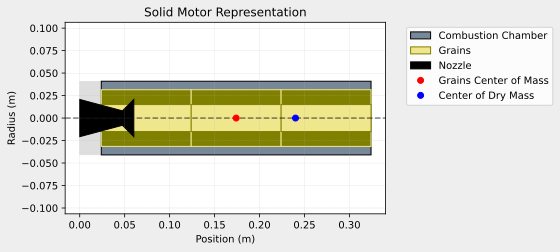

Nozzle Details
Nozzle Radius: 0.020715 m
Nozzle Throat Radius: 0.008 m

Grain Details
Number of Grains: 3
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.0315 m
Grain Inner Radius: 0.015 m
Grain Height: 0.1 m
Grain Volume: 0.000 m3
Grain Mass: 0.422 kg

Motor Details
Total Burning Time: 3.208 s
Total Propellant Mass: 1.265 kg
Structural Mass Ratio: 0.595
Average Propellant Exhaust Velocity: 1030.442 m/s
Average Thrust: 406.476 N
Maximum Thrust: 943.57289062 N at 1.169 s after ignition.
Total Impulse: 1303.975 Ns



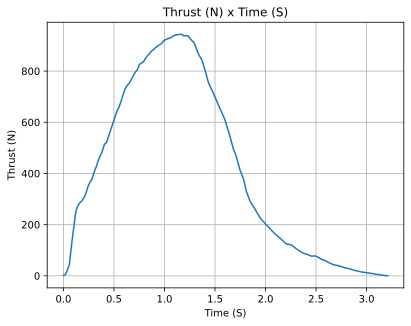

In [6]:
# SolidMotor
Dedalo_motor = SolidMotor(
    thrust_source=motor_data,
    dry_mass=motor_config["dry_mass"],
    dry_inertia=motor_config["dry_inertia"],
    nozzle_radius=motor_config["nozzle_radius"],
    grain_number=motor_config["grain_number"],
    grain_density=motor_config["grain_density"],
    grain_outer_radius=motor_config["grain_outer_radius"],
    grain_initial_inner_radius=motor_config["grain_initial_inner_radius"],
    grain_initial_height=motor_config["grain_initial_height"],
    grain_separation=motor_config["grain_separation"],
    grains_center_of_mass_position=motor_config["grains_center_of_mass_position"],
    center_of_dry_mass_position=motor_config["center_of_dry_mass_position"],
    nozzle_position=motor_config["nozzle_position"],
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=motor_config["throat_radius"],
    coordinate_system_orientation=motor_config["coordinate_system_orientation"],
)

print("\nSolidMotor initialized successfully!")
Dedalo_motor.draw()
Dedalo_motor.info()

Rocket object created successfully!


/home/vinicius/.platformio/penv/lib64/python3.13/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


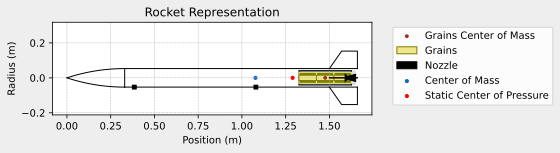

In [7]:
# Rocket without parachute (ballistic simulation)
Dedalo_rocket = Rocket(
    radius=rocket_data["radius"],
    mass=rocket_data["mass"],
    power_off_drag="poweroff.csv",
    power_on_drag="poweron.csv",
    inertia=rocket_data["inertia"],
    center_of_mass_without_motor=rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation=rocket_data["coordinate_system_orientation"],
)

print("Rocket object created successfully!")
Dedalo_rocket.add_motor(Dedalo_motor, position=1.65)

nose_cone = Dedalo_rocket.add_nose(
    length=rocket_data["nose_length"], kind=rocket_data["nose_type"], position=rocket_data["nose_position"]
)

fins = Dedalo_rocket.add_trapezoidal_fins(
    n=rocket_data["n_aletas"],
    root_chord=rocket_data["root_chord"],
    tip_chord=rocket_data["tip_chord"],
    span=rocket_data["span"],
    position=rocket_data["position"],
    cant_angle=rocket_data["cant_angle"]
)

rail_buttons = Dedalo_rocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)

Dedalo_rocket.draw()

In [8]:
# Ballistic flight — no parachute added
Dedalo_flight = Flight(
    rocket=Dedalo_rocket, environment=env, rail_length=4, inclination=85, heading=0
)

Dedalo_flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 475.58 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.002 c


Surface Wind Conditions

Frontal Surface Wind Speed: 3.50 m/s
Lateral Surface Wind Speed: 3.83 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.491 s
Rail Departure Velocity: 16.968 m/s
Rail Departure Stability Margin: 2.081 c
Rail Departure Angle of Attack: 17.450°
Rail Departure Thrust-Weight Ratio: 8.044
Rail Departure Reynolds Number: 1.161e+05


Burn out State

Burn out time: 3.208 s
Altitude at burn out: 787.025 m (ASL) | 311.449 m (AGL)
Rocket speed at burn out: 136.270 m/s
Freestream velocity

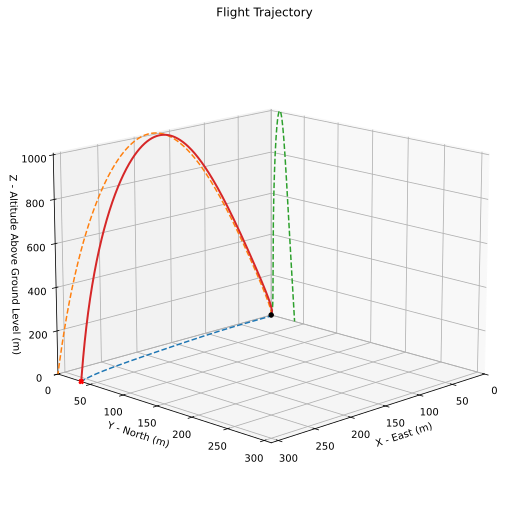

In [9]:
# Flight plots
Dedalo_flight.plots.trajectory_3d()

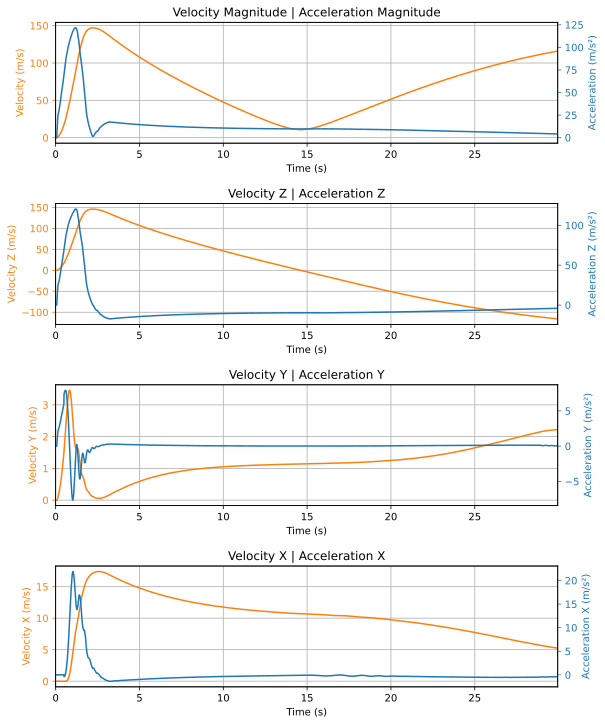

In [10]:
Dedalo_flight.plots.linear_kinematics_data()

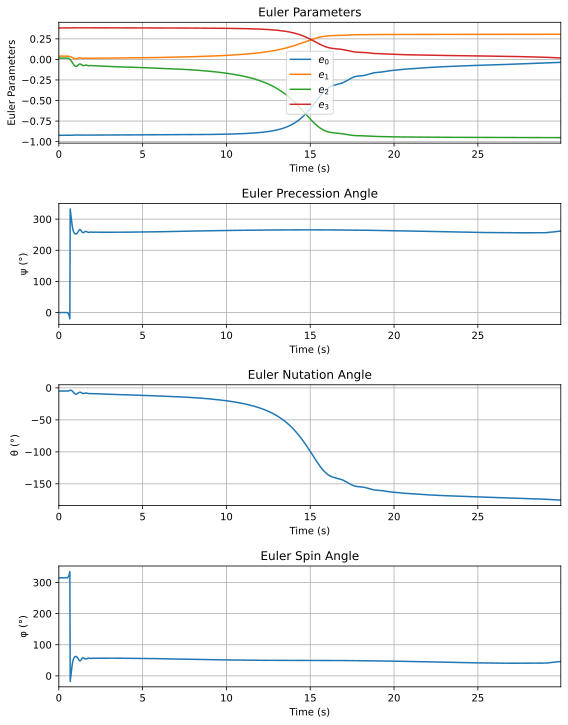

In [11]:
Dedalo_flight.plots.attitude_data()

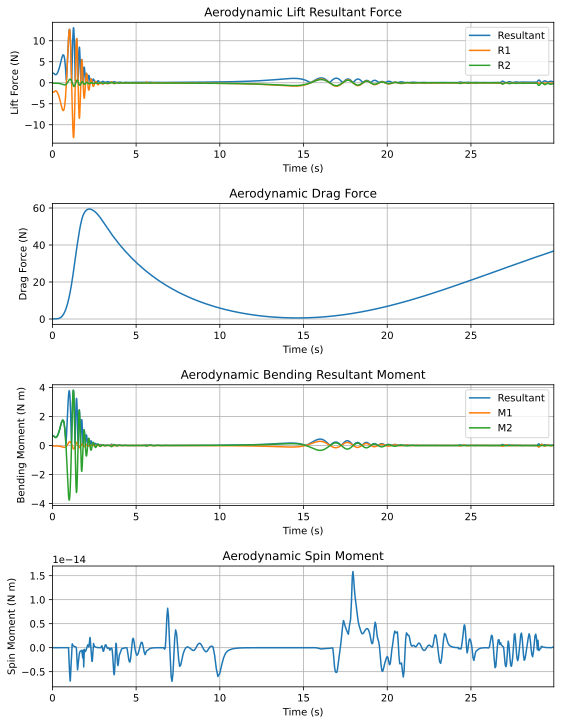

In [12]:
Dedalo_flight.plots.aerodynamic_forces()

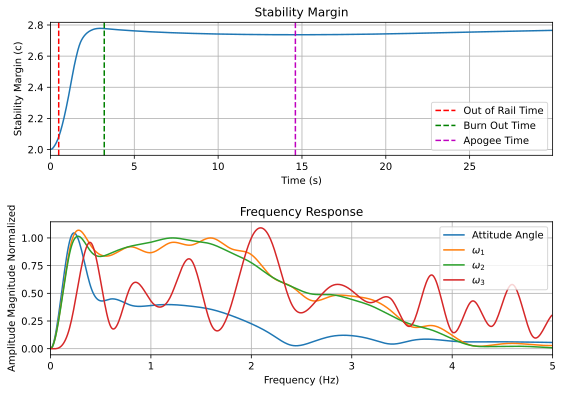

In [13]:
Dedalo_flight.plots.stability_and_control_data()

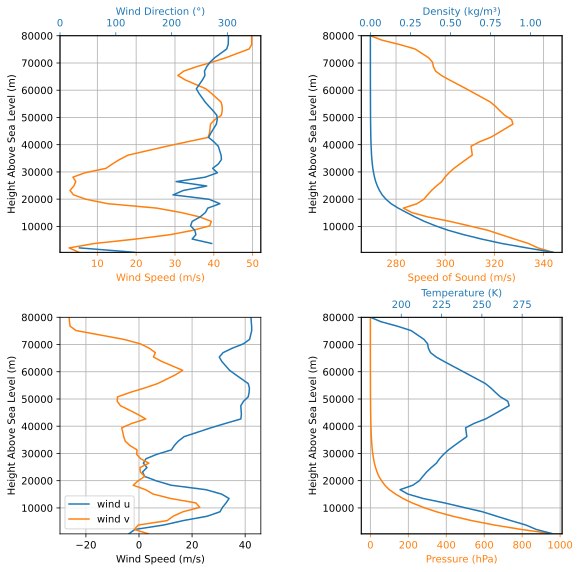

In [14]:
env.plots.atmospheric_model()